# Per-star NLE — inference on a stream we simulate ourselves (pocomc)

Same inference as `nle_inference_pocomc.ipynb`, but the observation is not
taken from the training-set files: `TRUE_PARAMS` is chosen here and the
stream is generated on the spot with `stream_sims.sims`, so the truth,
the star count, and the number of independent realizations are all under
direct control.

1. **Simulate the truth** — one dense noiseless stream at `TRUE_PARAMS`
   as the reference, plus one independently seeded simulator realization
   per observed realization, each observed once.
2. **Predictive check at the truth** — stars generated by the flow at
   `TRUE_PARAMS` vs. the observation. This tests the emulator alone.
3. **Posterior** — `pocomc` (preconditioned SMC) over the i.i.d. per-star
   likelihood with the simulation prior box (+ its detectability cut).
4. **Posterior predictive check** — stars at posterior `theta`, generated
   **both ways**: by the flow and by the true simulator. The gap between
   those panels is the emulator's contribution.

### Where measurement error enters (exactly once)

The simulator returns **noiseless** stars. `pre_transforms` is what turns a
noiseless stream into an observation: it perturbs the four noised features
and records the per-star sigmas in `xerr`. It must run **once** per star
set, because `UncertaintySampler` *appends* to `xerr` on every call -- a
second application would double the noise variance and widen `xerr` from 4
columns to 8, silently breaking the flow's context layout.

| star set | how noise gets in |
|---|---|
| observed realization | `pre_transforms`, once, on a fresh batch |
| flow samples | already included -- the flow learned the convolved density |
| simulator PPC / dense truth | `simulate_stars(..., xerr=...)`, once |

`check_measurement_once` enforces the column count, and the verification
cell below measures the realized noise against the recorded `xerr`.

In [22]:
%matplotlib inline
import importlib.util
import json
import sys
from pathlib import Path
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import pocomc
import corner

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import ks_2samp

# Absolute, so the notebook also runs from a copy elsewhere (compute nodes
# mount $HOME read-only, so batch execution happens under $SCRATCH).
PROJECT_DIR = Path('/home/tvnguyen/projects/sbi_stream/nle_stream_subhalo')
sys.path.append(str(PROJECT_DIR))
sys.path.append('/home/tvnguyen/projects/sbi_stream/sbi_stream_pipeline/')
sys.path.append('/home/tvnguyen/my_modules')   # Nbody_streams, via stream_sims.sims
from stream_sims import prior, sims

# set matplotlib cache dir to $SCRATCH, since $HOME is read-only on compute nodes
plt.rcParams['cache.directory'] = '/home/tvnguyen/.matplotlib'

from nle_stream_subhalo.nle import NLE
from nle_stream_subhalo.transforms import StarBatch, build_transformation

torch.set_num_threads(8)   # shared node: don't grab all CPUs
plt.style.use('/home/tvnguyen/default.mplstyle')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

KeyError: 'cache.directory is not a valid rc parameter (see rcParams.keys() for a list of valid parameters)'

## Settings

Everything the run depends on, in one place. `TRAIN_CONFIG` is only used to
find the run directory and to check that a checkpoint was trained with this
exact config; all model/data settings are read back from the run's own
snapshot.

In [3]:
TRAIN_CONFIG = PROJECT_DIR / 'configs/nsf_9params_75ds.py'

SEED = 10
N_OBS_STARS = 200          # stars in one observed realization
N_REALIZATIONS = 10        # independent simulator realizations of the truth
N_TRUTH_STARS = 5000       # flow stars generated at the true theta
N_TOTAL = 4096             # pocomc posterior/evidence particles
N_PPC_DRAWS = 100          # posterior thetas per predictive check, both ways
N_TOP = 3                  # best-fit thetas forward modelled afterwards
N_DENSE_PARTICLES = 5000   # oversampled truth realization (simulator max)

TRUE_PARAMS_DICT = dict(
    log_mass=1, log_radius=np.log10(0.3), v_rel_perp=35, v_rel_para=10,
    angle_pos_impact=0, angle_vel_delta=45, impact_param=1, time_impact=0.25,
    phi1_impact_today=-8
)
# TRUE_PARAMS_DICT = dict(
#     log_mass=1.3560,
#     log_radius=-0.0042,
#     v_rel_perp=44.6266,
#     v_rel_para=-32.7323,
#     angle_pos_impact=91.6980,
#     angle_vel_delta=30.0117,
#     impact_param=2.7734,
#     time_impact=0.1444,
#     phi1_impact_today=-11.5851
# )

PARAMS_ORDERING = prior.Prior.label_ordering
TRUE_PARAMS = np.array([TRUE_PARAMS_DICT[label] for label in PARAMS_ORDERING])

## Locate the latest checkpoint trained with this config

Runs are `<workdir>/<wandb_project>/<run_id>/`; `train_nle.py` drops a
verbatim copy of the config it ran with next to the checkpoints, so a run
counts as "this config" only if that copy is byte-identical.

In [4]:
def load_config(path):
    """Import a `get_config()` config module from a file path."""
    spec = importlib.util.spec_from_file_location('train_config', path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module.get_config()


def find_latest_checkpoint(config_path):
    """Find the newest checkpoint among runs of `config_path`.

    Args:
        config_path: Path to the training config (`configs/*.py`).

    Returns:
        (run_dir, checkpoint_path). `last.ckpt` wins when present -- it is
        the most recent epoch even while the run is still training.

    Raises:
        FileNotFoundError: If no run with a matching config snapshot has
            any checkpoint yet.
    """
    config = load_config(config_path)
    model_root = Path(config.workdir) / config.wandb_project
    config_text = Path(config_path).read_text()

    candidates = []
    for run_dir in model_root.iterdir():
        snapshot = run_dir / 'config_snapshot.py'
        ckpt_dir = run_dir / 'checkpoints'
        if not snapshot.is_file() or not ckpt_dir.is_dir():
            continue
        if snapshot.read_text() != config_text:
            continue
        ckpts = sorted(ckpt_dir.glob('*.ckpt'))
        if not ckpts:
            continue
        last = ckpt_dir / 'last.ckpt'
        ckpt = last if last.is_file() else max(
            ckpts, key=lambda p: p.stat().st_mtime)
        candidates.append((ckpt.stat().st_mtime, run_dir, ckpt))

    if not candidates:
        raise FileNotFoundError(
            f'No checkpointed run of {config_path} under {model_root}')
    _, run_dir, ckpt = max(candidates, key=lambda c: c[0])
    return run_dir, ckpt


RUN_DIR, CKPT_PATH = find_latest_checkpoint(TRAIN_CONFIG)
_state = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print(f'run        : {RUN_DIR}')
print(f'checkpoint : {CKPT_PATH.name}')
print(f'epoch      : {_state["epoch"]}  (global step {_state["global_step"]:,})')
for cb in _state.get('callbacks', {}).values():
    if isinstance(cb, dict) and cb.get('best_model_score') is not None:
        print(f'best score : {float(cb["best_model_score"]):.4f}'
              f'  [{Path(str(cb.get("best_model_path", ""))).name}]')

run        : /scratch/tvnguyen/trained_models/nle/9p_AAU_nle/fux1gqy9
checkpoint : last.ckpt
epoch      : 79  (global step 1,391,600)
best score : -23.8365  [epoch=77-step=1356810-loss=-23.8365.ckpt]


## Rebuild the model from the run snapshot

`pre_transforms` is excluded from the checkpoint's hyperparameters (it is a
callable), so it is rebuilt from the snapshotted `pre_transforms` config and
passed back in. Here it is used only to *draw a measurement realization* for
the observed stream — at inference the model itself never augments.

In [5]:
SNAPSHOT = json.loads((RUN_DIR / 'config_snapshot.json').read_text())
X_LABELS = tuple(SNAPSHOT['x_labels'])
LABELS = tuple(SNAPSHOT['labels'])
NDIM = len(LABELS)

pre_transforms = build_transformation(**SNAPSHOT['pre_transforms'])
model = NLE.load_from_checkpoint(CKPT_PATH, map_location=DEVICE)
model = model.eval().to(DEVICE)

print('x      :', X_LABELS)
print('theta  :', LABELS)
print('xerr   :', tuple(
    X_LABELS[a['feature_idx']] for a in SNAPSHOT['pre_transforms']['uncertainty_args']))

# The simulator, the prior and the flow must agree on what column 3 means.
assert tuple(LABELS) == tuple(PARAMS_ORDERING), (
    f'checkpoint labels {LABELS} != prior ordering {PARAMS_ORDERING}')

[NLE] Modeling p(x | theta,xerr)
[NLE] Flow built with 1,498,584 parameters
x      : ('phi1', 'phi2', 'vr', 'pm1', 'pm2', 'dist')
theta  : ('log_mass', 'log_radius', 'v_rel_perp', 'v_rel_para', 'angle_pos_impact', 'angle_vel_delta', 'impact_param', 'time_impact', 'phi1_impact_today')
xerr   : ('vr', 'pm1', 'pm2', 'dist')


## Is `TRUE_PARAMS` a stream the model could ever fit?

The flow was trained on draws from `stream_sims.prior.Prior`, and the
posterior is sampled inside that same box, so a truth outside it is
unreachable by construction: `log_prior` is `-inf` there, no pocomc particle
can visit it, and the flow never saw a stream like it in training. Worth
checking before spending a sampler run.

In [6]:
_prior = prior.Prior()
_idx = {label: i for i, label in enumerate(PARAMS_ORDERING)}
inside = (TRUE_PARAMS >= _prior.prior_min) & (TRUE_PARAMS <= _prior.prior_max)

print(f'{"param":>18} {"value":>10} {"prior min":>10} {"prior max":>10}  ok')
for i, label in enumerate(PARAMS_ORDERING):
    flag = ' ' if inside[i] else '  <-- OUTSIDE'
    print(f'{label:>18} {TRUE_PARAMS[i]:>10.3f} {_prior.prior_min[i]:>10.3f} '
          f'{_prior.prior_max[i]:>10.3f} {str(bool(inside[i])):>5}{flag}')

detectable = bool(_prior.accept(
    TRUE_PARAMS[_idx['log_mass']], TRUE_PARAMS[_idx['impact_param']],
    TRUE_PARAMS[_idx['v_rel_perp']], TRUE_PARAMS[_idx['v_rel_para']]))
print(f'\ndelta_V > 3 km/s detectability cut : {detectable}')
print(f'log_prior(TRUE_PARAMS)             : '
      f'{float(_prior.log_prior(TRUE_PARAMS[None])[0])}')
if not (inside.all() and detectable):
    print('\nWARNING: the truth is outside the prior support. The simulator '
          'will still\nproduce this stream, but the posterior cannot cover '
          'it -- treat the\nrecovered theta as a projection onto the prior '
          'box, not as a bias measurement.')

             param      value  prior min  prior max  ok
          log_mass      1.000     -1.000      1.699  True 
        log_radius     -0.523     -2.000      0.398  True 
        v_rel_perp     35.000      0.000    200.000  True 
        v_rel_para     10.000   -200.000    200.000  True 
  angle_pos_impact      0.000      0.000    180.000  True 
   angle_vel_delta     45.000    -90.000     90.000  True 
      impact_param      1.000      0.500      5.000  True 
       time_impact      0.250      0.000      0.450  True 
 phi1_impact_today     -8.000    -15.000     -8.000  True 

delta_V > 3 km/s detectability cut : True
log_prior(TRUE_PARAMS)             : -24.754960586614065


## Generating the observed stream with the true simulator

`simulate_stream` returns the raw, **noiseless** simulator output, reordered
from its own `NODE_FEATURE_NAMES` into `X_LABELS`.

The simulator is deterministic at fixed theta *unless given a seed*: the
particle-spray escape offsets come from a `default_rng(0)` built inside
`Nbody_streams`, and the release times are a fixed subsample of
`DISTRIB_STRIPPING`. `sims.simulate_one(..., seed=...)` randomizes both, so
each call returns an independent realization of the same stream.

Everything below passes a seed. Each observed realization is therefore its
own simulator run — they differ by the stream realization itself, not only
by which stars were drawn and what noise landed on them. The dense stream
is still simulated once and kept as the reference truth.

In [7]:
SIM_COLS = [sims.NODE_FEATURE_NAMES.index(k) for k in X_LABELS]
ERR_COLS = [a['feature_idx']
            for a in SNAPSHOT['pre_transforms']['uncertainty_args']]
N_ERR = len(ERR_COLS)


def check_measurement_once(batch):
    """Assert `batch` carries exactly one measurement-model application.

    `UncertaintySampler` appends a column to `batch.xerr` every time it
    runs, so a batch put through `pre_transforms` twice ends up with
    2 * N_ERR columns and twice the noise variance. Cheap guard, since the
    failure is otherwise silent until the flow's context width mismatches.

    Args:
        batch: StarBatch to check.

    Returns:
        The same batch, so this can wrap a call.

    Raises:
        ValueError: If `xerr` is missing or has the wrong width.
    """
    if batch.xerr is None:
        raise ValueError('batch has no xerr: the measurement model never ran')
    if batch.xerr.shape[1] != N_ERR:
        raise ValueError(
            f'xerr has {batch.xerr.shape[1]} columns, expected {N_ERR}: '
            'the measurement model ran more than once')
    return batch


def simulate_stream(theta, n_particles, seed=None):
    """One noiseless stream from the true simulator, in `X_LABELS` order.

    Args:
        theta: (NDIM,) physical parameters.
        n_particles: Particles to simulate (<= 5000, the snapshot's count).
        seed: Randomizes the realization -- both the release times and the
            particle-spray escape offsets. None reuses the one fixed
            realization, identical for every call at this theta.

    Returns:
        (n_particles, n_features) noiseless stars.

    Raises:
        RuntimeError: If the simulator rejected these parameters.
    """
    _, feats = sims.simulate_one(np.asarray(theta, dtype=np.float64),
                                 num_particles=n_particles, seed=seed)
    if feats is None:
        raise RuntimeError(f'simulator failed at theta={theta}')
    return feats[:, SIM_COLS]


def make_observation(stream, n_stars=None, seed=SEED):
    """Observe a noiseless stream once, subsampling it first if asked.

    `pre_transforms` is applied to a *fresh* StarBatch built from noiseless
    stars -- never to one that already carries `xerr` -- so the measurement
    model enters exactly once. It draws with torch's global RNG, hence the
    explicit `manual_seed`.

    Args:
        stream: (n_particles, n_features) noiseless stars.
        n_stars: Stars to draw, without replacement. None observes every
            star, which is what independent realizations want: each is
            already simulated at the star count it needs.
        seed: Seed for both the subsampling and the noise draw.

    Returns:
        (obs, idx): the observed StarBatch and the parent rows it came
        from, kept so the realized noise can be checked against `xerr`.
    """
    rng = np.random.default_rng(seed)
    idx = (np.arange(len(stream)) if n_stars is None
           else rng.choice(len(stream), size=n_stars, replace=False))
    torch.manual_seed(int(rng.integers(2 ** 31)))
    batch = StarBatch(x=torch.tensor(stream[idx], dtype=torch.float32))
    return check_measurement_once(pre_transforms(batch)), idx


def simulate_stars(thetas, n_particles, xerr=None, seed=SEED):
    """Pooled simulated stars, optionally observed through `xerr`.

    Every theta gets its own simulator seed drawn from `seed`, so pooling
    many draws pools *independent* realizations. Sharing one realization
    instead stacks the same escape offsets and release times over and over,
    and the pooled panel shows discrete filaments rather than a density.

    Args:
        thetas: (NDIM,) or (n_theta, NDIM) physical parameters.
        n_particles: Particles per simulated stream.
        xerr: Per-star sigmas (n, N_ERR) to draw measurement noise from,
            resampled with replacement since simulated stars have no
            correspondence to observed ones. None leaves the stars
            noiseless.
        seed: Seeds both the per-realization simulator draws and the noise.

    Returns:
        ((n_total, n_features) stars, number of failed simulations).
    """
    rng = np.random.default_rng(seed)
    pool = None if xerr is None else np.asarray(xerr)
    out, n_failed = [], 0
    for theta in np.atleast_2d(thetas):
        try:
            x = simulate_stream(theta, n_particles,
                                seed=int(rng.integers(2 ** 32)))
        except RuntimeError:
            n_failed += 1
            continue
        if pool is not None:
            sigma = pool[rng.integers(len(pool), size=len(x))]
            for col, feature_idx in enumerate(ERR_COLS):
                x[:, feature_idx] += rng.normal(0.0, sigma[:, col])
        out.append(x)
    return np.concatenate(out), n_failed


def to_numpy(tensor):
    """Detach a possibly-GPU tensor to a numpy array."""
    return tensor.detach().cpu().numpy()


def stream_limits(*streams, pad_frac=0.05, percentile=99.5):
    """Per-feature axis limits shared by every stream grid.

    A central percentile range rather than min/max, so a handful of flung
    particles cannot flatten every panel. Pass the reference set(s) -- the
    simulated truth and one observed realization -- and reuse the result
    everywhere, so panels stay comparable across figures.

    Args:
        *streams: (n_stars, n_features) arrays to take the range over.
        pad_frac: Fraction of the range added on each side.
        percentile: Central range kept, in percent.

    Returns:
        List of (lo, hi) per feature, in `X_LABELS` order.
    """
    stacked = np.concatenate([np.asarray(s) for s in streams])
    half = (100 - percentile) / 2
    lims = []
    for col in range(stacked.shape[1]):
        lo, hi = np.percentile(stacked[:, col], [half, 100 - half])
        pad = pad_frac * (hi - lo)
        lims.append((lo - pad, hi + pad))
    return lims


def plot_stream_grid(columns, lims, s=1, alpha=0.5, dpi=150):
    """phi1 vs every other feature, one column per star set.

    Every panel is drawn on `lims`, so two calls with the same limits can
    be compared directly. Stars outside the frame are reported per column
    rather than silently cropped -- the flow's tails run wider than the
    simulator's.

    Args:
        columns: List of (title, stars, color) triples.
        lims: Per-feature (lo, hi) from `stream_limits`.
        s, alpha, dpi: Passed through to the scatter / figure.

    Returns:
        (fig, axes).
    """
    n_rows = len(X_LABELS) - 1
    fig, axes = plt.subplots(
        n_rows, len(columns), figsize=(5 * len(columns), 1.4 * n_rows + 0.6),
        dpi=dpi, sharex=True, sharey='row', squeeze=False)

    for j, (title, stars, color) in enumerate(columns):
        stars = np.asarray(stars)
        inside = np.ones(len(stars), dtype=bool)
        for col in range(stars.shape[1]):
            inside &= ((stars[:, col] >= lims[col][0])
                       & (stars[:, col] <= lims[col][1]))
        for i in range(n_rows):
            axes[i, j].scatter(stars[:, 0], stars[:, i + 1], s=s,
                               alpha=alpha, color=color)
        axes[0, j].set_title(f'{title}\nn = {len(stars):,}', fontsize=9)
        axes[-1, j].set_xlabel(X_LABELS[0])
        off_frame = 1.0 - inside.mean()
        if off_frame > 0.001:
            axes[0, j].text(
                0.98, 0.93, f'{off_frame:.1%} off-frame', color='crimson',
                fontsize=7, ha='right', va='top',
                transform=axes[0, j].transAxes)

    for i in range(n_rows):
        axes[i, 0].set_ylabel(X_LABELS[i + 1])
        axes[i, 0].set_ylim(*lims[i + 1])   # sharey='row'
    axes[0, 0].set_xlim(*lims[0])           # sharex=True
    fig.subplots_adjust(wspace=0.0, hspace=0.0)
    return fig, axes

In [8]:
# The dense noiseless truth, kept as the reference stream everything is
# plotted against.
target_stream_dense = simulate_stream(
    TRUE_PARAMS, N_DENSE_PARTICLES, seed=SEED)
print(f'dense truth: {len(target_stream_dense):,} noiseless stars')

# Observed once, for the display panels only. Never observe an already
# observed array: that would put every star through the measurement model
# twice, leaving obs.x dispersed by sqrt(sigma_1^2 + sigma_2^2) while
# obs.xerr records only sigma_2.
dense_obs, _ = make_observation(target_stream_dense, seed=SEED)
target_stream_dense_obs = to_numpy(dense_obs.x)
target_stream_dense_err = to_numpy(dense_obs.xerr)

# Each realization is its own simulator run at N_OBS_STARS particles: no
# subsampling of a shared parent, so they differ by the stream realization
# as well as by the noise. Separate seed streams for the two so the
# simulation and the observation of it stay independent.
sim_seq, obs_seq = np.random.SeedSequence(SEED).spawn(2)
target_parents, target_streams, target_idx = [], [], []
for sim_child, obs_child in zip(sim_seq.spawn(N_REALIZATIONS),
                                obs_seq.spawn(N_REALIZATIONS)):
    parent_i = simulate_stream(
        TRUE_PARAMS, N_OBS_STARS, seed=int(sim_child.generate_state(1)[0]))
    obs_i, idx_i = make_observation(parent_i, seed=obs_child)
    target_parents.append(parent_i)
    target_streams.append(obs_i)
    target_idx.append(idx_i)

# The first realization is the one everything downstream is conditioned on.
obs, obs_idx = target_streams[0], target_idx[0]
print(f'{N_REALIZATIONS} independent realizations of {N_OBS_STARS} stars; '
      f'xerr columns = {obs.xerr.shape[1]} (expected {N_ERR})')

# Axis limits every stream grid reuses: the truth's own range, widened by
# one observed realization so the measurement scatter is not clipped.
TRUTH_LIMS = stream_limits(target_stream_dense_obs, to_numpy(obs.x))


dense truth: 5,000 noiseless stars
10 independent realizations of 200 stars; xerr columns = 4 (expected 4)


### Verification: the measurement model ran exactly once

`check_measurement_once` only counts `xerr` columns, so it cannot see a
star set that was noised, written back to an array, and then noised again
in a *fresh* batch -- the second pass rebuilds `xerr` from scratch and the
column count still checks out. What does catch it is the pull,
`(observed - noiseless) / xerr`, which is a unit Gaussian iff the noise
that is in the data is the noise `xerr` claims. Anything much above 1 means
the flow is being asked to explain scatter it was never told about, and the
posterior will run off to whatever corner of the prior box tolerates it.

In [9]:
def pull_statistics(obs, parent, idx):
    """Std of (realized noise / recorded sigma) per noised feature.

    Args:
        obs: Observed StarBatch from `make_observation`.
        parent: (n_particles, n_features) noiseless stream it came from.
        idx: Parent rows the observation was drawn from.

    Returns:
        (N_ERR,) array; ~1.0 per feature iff the measurement model ran
        exactly once.
    """
    resid = to_numpy(obs.x) - parent[idx]
    err = to_numpy(obs.xerr)
    return np.array([float(np.std(resid[:, feature_idx] / err[:, col]))
                     for col, feature_idx in enumerate(ERR_COLS)])


print(f'{"realization":>12} ' + ' '.join(
    f'{X_LABELS[i]:>8}' for i in ERR_COLS))
for j, (obs_j, parent_j, idx_j) in enumerate(
        zip(target_streams, target_parents, target_idx)):
    pulls = pull_statistics(obs_j, parent_j, idx_j)
    flag = '' if np.all(pulls < 1.5) else '   <-- OVER-NOISED'
    print(f'{j:>12} ' + ' '.join(f'{p:>8.2f}' for p in pulls) + flag)

 realization       vr      pm1      pm2     dist
           0     1.05     1.05     1.07     1.00
           1     1.03     0.95     1.02     0.98
           2     1.07     1.02     1.10     0.99
           3     0.99     0.95     1.06     0.98
           4     0.91     1.05     0.97     1.00
           5     1.02     0.98     1.04     0.90
           6     0.94     0.98     0.99     0.97
           7     1.00     1.01     1.06     0.93
           8     1.02     0.95     1.00     1.02
           9     0.97     0.93     0.99     0.98


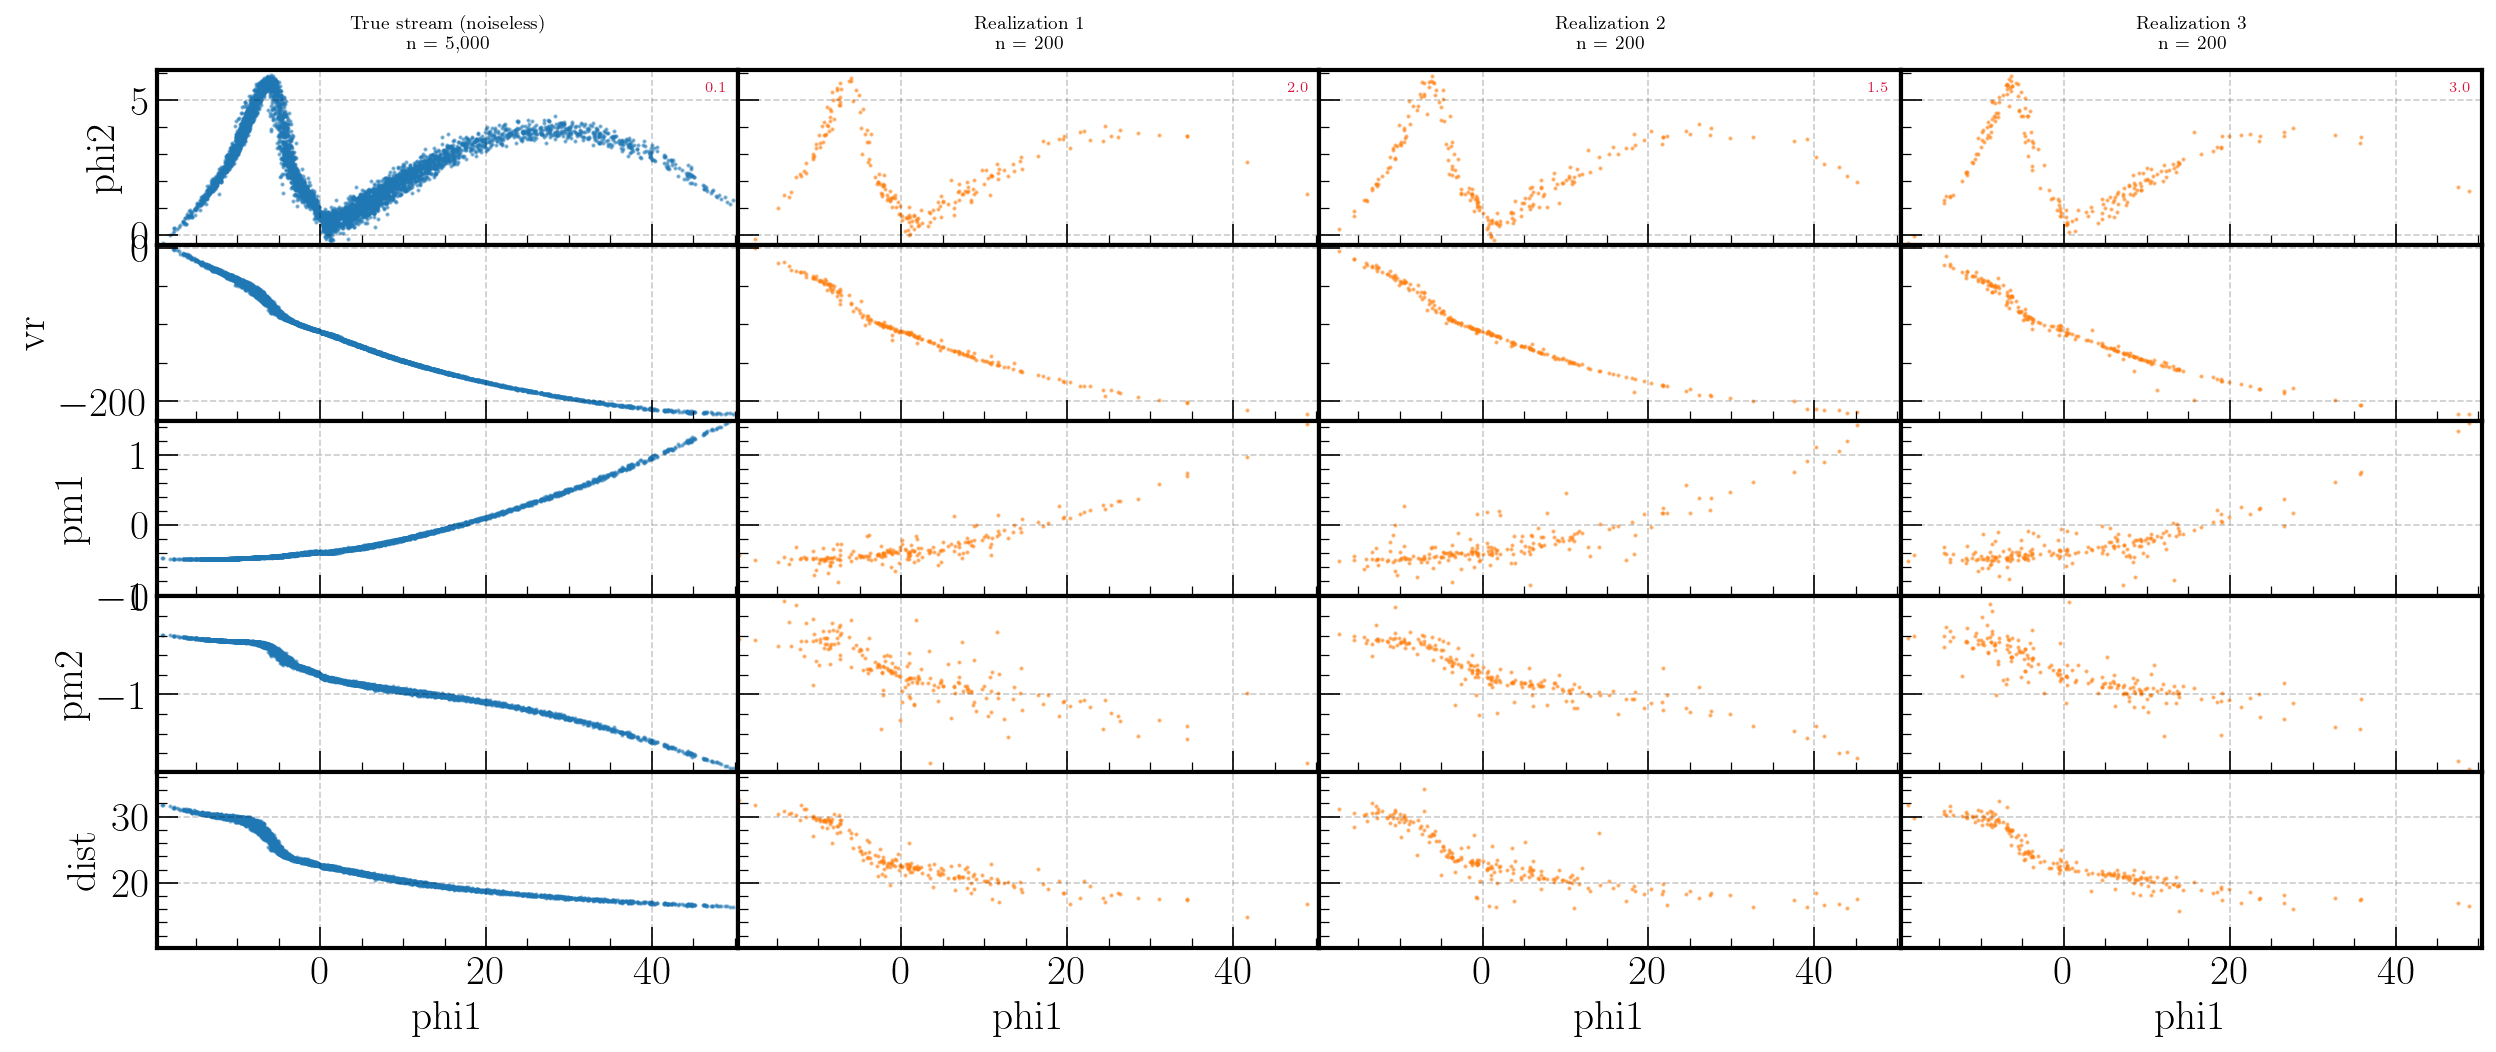

In [10]:
n_realization_plot = 3

plot_stream_grid(
    [('True stream (noiseless)', target_stream_dense, 'C0')]
    + [(f'Realization {j + 1}', to_numpy(target_streams[j].x), 'C1')
       for j in range(n_realization_plot)],
    TRUTH_LIMS)
plt.show()

We can also use the NLE to sample the observed stream from the true
parameters, to check that the flow is a good emulator of the simulator.
The flow's samples are *already* noise-convolved -- it was trained on stars
that had been through `pre_transforms` -- so nothing further is added to
them. Conditioning on `obs.xerr` makes their noise level match the
observation's star for star.

In [11]:
def sample_stars(thetas, n_stars, xerr, seed=SEED):
    """Draw `n_stars` stars from the flow's p(x | theta, xerr) per theta.

    The flow's context is (theta, xerr) alone -- it has no notion of
    *which* star it is drawing -- so a generated star needs nothing from
    the observation but a sigma. Its samples are already noise-convolved
    (it was trained on stars that had been through `pre_transforms`), so
    nothing further may be added to them.

    Args:
        thetas: (NDIM,) or (n_theta, NDIM) physical parameters.
        n_stars: Stars drawn per theta.
        xerr: (n, N_ERR) sigma pool, rows resampled with replacement --
            generated stars have no correspondence to observed ones, so
            each just needs a sigma from the same distribution.
        seed: Seed for the sigma resampling (the flow's own draw uses
            torch's global RNG).

    Returns:
        (n_theta * n_stars, n_features) physical samples.

    Raises:
        ValueError: If `xerr` is not N_ERR columns wide, which would mean
            the measurement model had been applied more than once.
    """
    pool = np.asarray(xerr)
    if pool.ndim != 2 or pool.shape[1] != N_ERR:
        raise ValueError(f'xerr has shape {pool.shape}, expected (n, {N_ERR})')

    rng = np.random.default_rng(seed)
    thetas = np.atleast_2d(thetas)
    n_rows = len(thetas) * n_stars
    sigma = pool[rng.integers(len(pool), size=n_rows)]
    batch = StarBatch(
        x=torch.zeros(n_rows, len(X_LABELS)),   # unused: context only
        xerr=torch.tensor(sigma, dtype=torch.float32),
        theta=torch.tensor(np.repeat(thetas, n_stars, axis=0),
                           dtype=torch.float32))
    samples = model.sample(batch, num_samples=1)
    return samples.reshape(n_rows, len(X_LABELS)).cpu().numpy()

In [12]:
flow_samples_dense = sample_stars(TRUE_PARAMS, N_TRUTH_STARS, to_numpy(obs.xerr))

# sample realizations
flow_samples_realizations = []
for i in range(N_REALIZATIONS):
    flow_samples_i = sample_stars(TRUE_PARAMS, N_OBS_STARS, to_numpy(target_streams[i].xerr))
    flow_samples_realizations.append(flow_samples_i)

In [23]:
plot_stream_grid(
    [('Flow at TRUE_PARAMS', flow_samples_dense, 'C2')]
    + [(f'Flow realization {j + 1}', flow_samples_realizations[j], 'C3')
       for j in range(n_realization_plot)],
    TRUTH_LIMS)   # same limits as the simulated-truth grid above
plt.show()

PermissionError: [Errno 13] Permission denied: '/home/tvnguyen/.cache/matplotlib/tex.cache/40/fe'

<Figure size 3000x1140 with 20 Axes>

### Likelihood and prior

Stars are i.i.d. given `theta`, so the stream log-likelihood is the sum of
per-star `model.log_prob`. pocomc keeps prior and likelihood separate (it
needs to sample the prior and to temper the likelihood), so unlike the emcee
version there is no combined log-posterior.

The prior is the simulation box (`stream_sims.prior.Prior`) including its
`delta_V > 3 km/s` detectability cut. pocomc's own `Prior` class assumes
independent per-parameter scipy distributions, which that cut is not, so it
is wrapped in the four attributes pocomc actually uses.

In [14]:
PRIOR = prior.Prior()
PRIOR_MIN, PRIOR_MAX = PRIOR.prior_min, PRIOR.prior_max


class StreamPrior:
    """`stream_sims.prior.Prior` in the interface pocomc expects."""

    def logpdf(self, theta):
        """Log prior density of (n, NDIM) rows; -inf outside the cut."""
        return PRIOR.log_prior(np.atleast_2d(theta))

    def rvs(self, size=1):
        """Draw (size, NDIM) rows from the accepted prior region."""
        return PRIOR.sample_prior(size)

    @property
    def bounds(self):
        return np.stack([PRIOR_MIN, PRIOR_MAX], axis=1)

    @property
    def dim(self):
        return NDIM


def make_loglike(obs):
    """Build the vectorized stream log-likelihood for one observation.

    Args:
        obs: Observed StarBatch (`x` and `xerr` set), held fixed.

    Returns:
        Callable mapping (n, NDIM) physical theta to (n,) log-likelihoods,
        for `pocomc.Sampler(vectorize=True)`.
    """
    obs_x = obs.x.to(DEVICE)
    obs_err = obs.xerr.to(DEVICE)
    n_stars = obs_x.shape[0]

    @torch.no_grad()
    def loglike(theta):
        theta = torch.as_tensor(
            np.atleast_2d(theta), dtype=torch.float32, device=DEVICE)
        n_theta = theta.shape[0]
        # Row i * n_stars + n is (theta_i, star_n): tile the stars, hold
        # each theta for a whole block, so `view` below regroups by theta.
        batch = StarBatch(
            x=obs_x.repeat(n_theta, 1),
            xerr=obs_err.repeat(n_theta, 1),
            theta=theta.repeat_interleave(n_stars, dim=0))
        return model.log_prob(batch).view(n_theta, n_stars).sum(1).cpu().numpy()

    return loglike


def run_posterior(obs, theta_true=None, n_total=N_TOTAL, seed=SEED,
                  progress=False):
    """Sample the posterior of theta for one observed stream.

    `theta_true` is unused -- pocomc starts from the prior, not from a ball
    around the truth -- and is accepted only to match the emcee variant's
    signature.

    Returns:
        (sampler, chain): the pocomc sampler and equal-weight posterior
        samples (importance weights resolved by resampling).
    """
    sampler = pocomc.Sampler(
        prior=StreamPrior(), likelihood=make_loglike(obs), vectorize=True,
        random_state=seed)
    sampler.run(n_total=n_total, n_evidence=n_total, progress=progress)
    chain, _, _ = sampler.posterior(resample=True)
    return sampler, chain


def report_diagnostics(sampler):
    """Print the evidence and the importance-weight efficiency."""
    samples, weights, _, _ = sampler.posterior()
    weights = weights / weights.sum()
    logz, logz_err = sampler.evidence()
    ess = 1.0 / np.sum(weights ** 2)
    print(f'log Z            : {logz:.2f} +- {logz_err:.2f}')
    print(f'weighted samples : {len(samples)}')
    print(f'importance ESS   : {ess:.0f}  ({100 * ess / len(samples):.0f}% '
          f'efficiency)')


def plot_sampler_diagnostic(sampler, theta_true=None):
    """SMC progress per iteration: temperature, evidence, and ESS.

    `sampler.results` is flat over particles, not iterations, so each
    per-iteration quantity is read off the first particle of each `iter`.
    """
    res = sampler.results
    iters = np.asarray(res['iter'])
    unique = np.unique(iters)
    first = np.array([np.flatnonzero(iters == i)[0] for i in unique])
    beta = np.asarray(res['beta'])[first]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3), dpi=100)
    axes[0].plot(unique, beta, marker='.')
    axes[0].set_xlabel('SMC iteration')
    axes[0].set_ylabel('beta (temperature)')
    axes[1].plot(beta, np.asarray(res['logz'])[first], marker='.')
    axes[1].set_xlabel('beta')
    axes[1].set_ylabel('log Z')
    axes[2].plot(unique, np.asarray(res['ess'])[first], marker='.')
    axes[2].set_xlabel('SMC iteration')
    axes[2].set_ylabel('ESS')
    fig.tight_layout()
    return fig

### Plotting

In [15]:
def _padded_lim(values, pad_frac=0.3):
    """Min/max of `values` padded by a fraction of its range."""
    lo, hi = float(np.min(values)), float(np.max(values))
    span = (hi - lo) or (abs(hi) or 1.0)
    return lo - pad_frac * span, hi + pad_frac * span


def plot_predictive(obs, panels, xlim=(-50, 50)):
    """Observed stream and each generated set, phi1 vs every other feature.

    Args:
        obs: Observed StarBatch.
        panels: List of (title, stars) pairs, one extra column each.
        xlim: Shared phi1 range.
    """
    obs_x = to_numpy(obs.x)
    columns = [('observed', obs_x)] + list(panels)
    n_rows = len(X_LABELS) - 1
    fig, axes = plt.subplots(
        n_rows, len(columns), figsize=(5 * len(columns), 2.4 * n_rows),
        dpi=100, sharex=True, sharey='row', squeeze=False)
    for j, (title, stars) in enumerate(columns):
        for i in range(n_rows):
            axes[i, j].scatter(stars[:, 0], stars[:, i + 1], s=5,
                               alpha=0.5 if j == 0 else 0.1)
        axes[0, j].set_title(title)
        axes[-1, j].set_xlabel('phi1')
    for i in range(n_rows):
        axes[i, 0].set_ylabel(X_LABELS[i + 1])
        axes[i, 0].set_ylim(_padded_lim(obs_x[:, i + 1]))   # sharey='row'
    axes[0, 0].set_xlim(xlim)
    fig.tight_layout()
    return fig


def plot_marginals(obs, panels, bins=40):
    """1D marginals of the observed stream and each generated set."""
    obs_x = to_numpy(obs.x)
    fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=100)
    for i, ax in enumerate(axes.flat):
        edges = np.linspace(*_padded_lim(obs_x[:, i], 0.1), bins + 1)
        ax.hist(obs_x[:, i], bins=edges, density=True, histtype='step',
                lw=2, color='k', label='observed')
        for (title, stars), color in zip(panels, ['C0', 'C1', 'C2']):
            ax.hist(stars[:, i], bins=edges, density=True, histtype='step',
                    lw=1.5, color=color, label=title)
        ax.set_xlabel(X_LABELS[i])
    axes[0, 0].legend(fontsize=7)
    fig.tight_layout()
    return fig


def summarize_posterior(chain, theta_true):
    """Print per-parameter median, 1-sigma interval, and z-score vs truth."""
    lo, med, hi = np.percentile(chain, [16, 50, 84], axis=0)
    print(f'{"param":>18} {"truth":>9} {"median":>9} {"-1sig":>8} '
          f'{"+1sig":>8} {"z":>6}')
    for i, lab in enumerate(LABELS):
        sigma = (hi[i] - lo[i]) / 2
        z = (med[i] - theta_true[i]) / sigma if sigma > 0 else np.nan
        print(f'{lab:>18} {theta_true[i]:>9.3f} {med[i]:>9.3f} '
              f'{med[i] - lo[i]:>8.3f} {hi[i] - med[i]:>8.3f} {z:>6.2f}')

## Analysis

One call on a supplied observation: predictive check at the truth,
posterior, diagnostics, then the posterior predictive check both ways.

In [18]:
def analyze_observation(obs, theta_true, name='truth', progress=False):
    """Run the full inference-only check for one observed realization.

    Args:
        obs: Observed StarBatch from `make_observation`.
        theta_true: (NDIM,) parameters the stream was simulated at.
        name: Label used in plot titles.

    Returns:
        Dict with the observation, true theta, sampler, posterior samples,
        and the generated star sets.
    """
    check_measurement_once(obs)
    xerr = to_numpy(obs.xerr)
    print(f'=== {name}: {obs.x.shape[0]} stars, '
          f'log_mass = {theta_true[0]:.3f} '
          f'({10 ** theta_true[0] * 1e7:.2e} Msun) ===')

    print('\n--- predictive check at the true theta ---')
    truth_stars = sample_stars(theta_true, N_TRUTH_STARS, xerr)
    # The same truth with 25x the stars, observed through the same sigmas:
    # the reference every generated panel should be read against, since the
    # observed panel's own scatter is sampling-noise dominated.
    dense_truth, _ = simulate_stars(
        theta_true, N_DENSE_PARTICLES, xerr=xerr)
    print(f'oversampled truth: {len(dense_truth):,} stars vs '
          f'{obs.x.shape[0]} observed')
    plot_predictive(obs, [(f'{name}: truth, {N_DENSE_PARTICLES} particles',
                           dense_truth),
                          (f'{name}: flow at theta_true', truth_stars)])
    plt.show()
    plot_marginals(obs, [('truth, oversampled', dense_truth),
                         ('flow at theta_true', truth_stars)])
    plt.show()

    print('\n--- posterior ---')
    sampler, chain = run_posterior(obs, theta_true, progress=progress)
    report_diagnostics(sampler)
    print()
    summarize_posterior(chain, theta_true)
    plot_sampler_diagnostic(sampler, theta_true)
    plt.show()
    corner.corner(chain, labels=list(LABELS), truths=list(theta_true),
                  show_titles=True, title_fmt='.2f')
    plt.show()

    print('\n--- posterior predictive check: flow vs simulator ---')
    rng = np.random.default_rng(SEED)
    draws = chain[rng.choice(len(chain), N_PPC_DRAWS, replace=False)]
    ppc_flow = sample_stars(draws, N_OBS_STARS, xerr)
    ppc_sim, n_failed = simulate_stars(draws, N_OBS_STARS, xerr=xerr)
    print(f'{N_PPC_DRAWS - n_failed}/{N_PPC_DRAWS} simulations succeeded '
          f'({len(ppc_sim):,} stars); flow drew {len(ppc_flow):,}')
    plot_predictive(obs, [
        (f'{name}: truth, {N_DENSE_PARTICLES} particles', dense_truth),
        (f'{name}: PPC (flow)', ppc_flow),
        (f'{name}: PPC (simulator)', ppc_sim)])
    plt.show()
    plot_marginals(obs, [('truth, oversampled', dense_truth),
                         ('PPC (flow)', ppc_flow),
                         ('PPC (simulator)', ppc_sim)])
    plt.show()

    return dict(obs=obs, theta_true=theta_true, sampler=sampler, chain=chain,
                truth_stars=truth_stars, dense_truth=dense_truth,
                ppc_flow=ppc_flow, ppc_sim=ppc_sim)


results = {}

=== truth: 200 stars, log_mass = 1.000 (1.00e+08 Msun) ===

--- predictive check at the true theta ---
oversampled truth: 5,000 stars vs 200 observed


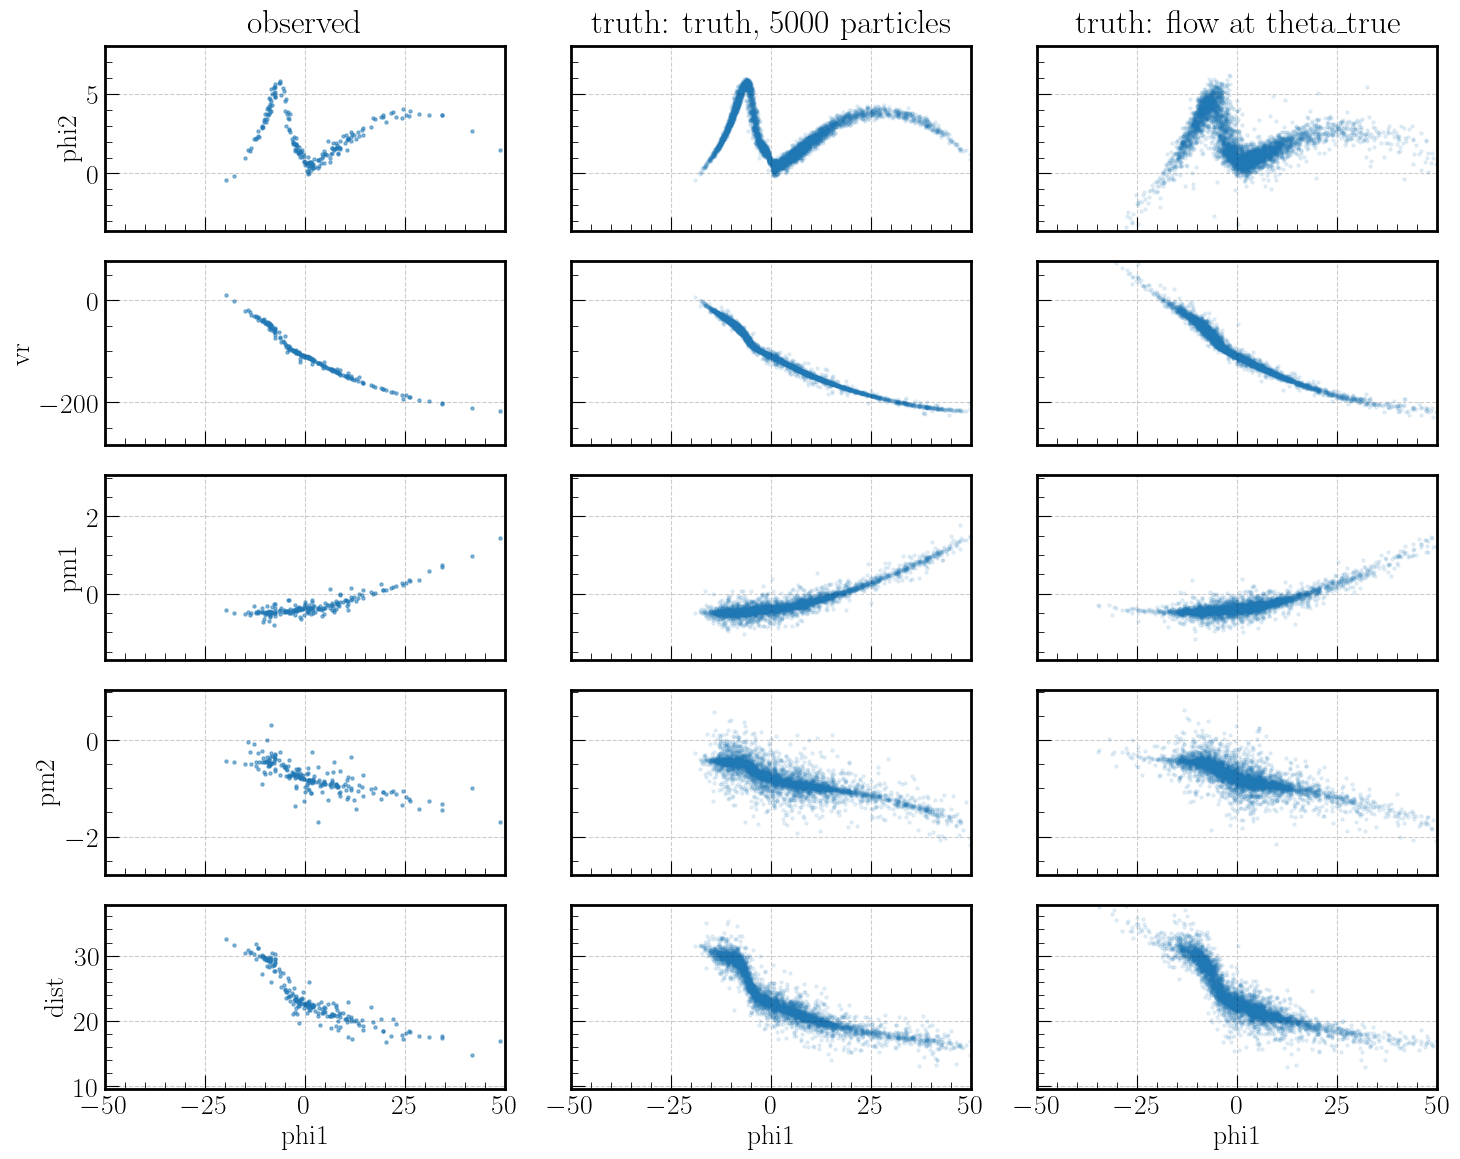

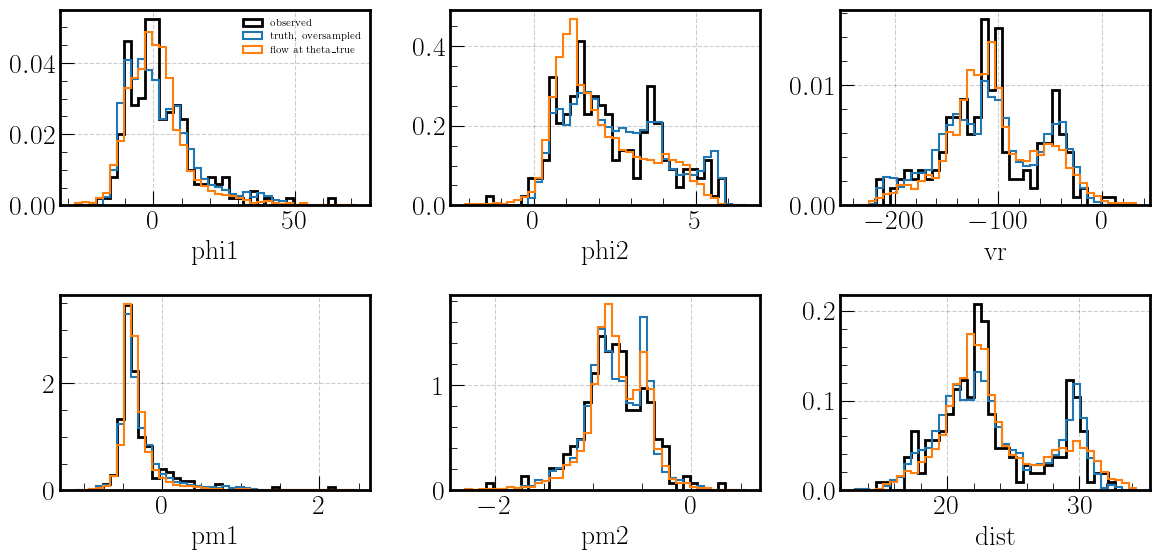


--- posterior ---


Iter: 47it [04:22,  5.58s/it, beta=1, calls=114094, ESS=3967, logZ=4.59e+3, logP=4.6e+3, acc=0.724, steps=8, eff=1]      


log Z            : 4590.77 +- 0.02
weighted samples : 4484
importance ESS   : 4194  (94% efficiency)

             param     truth    median    -1sig    +1sig      z
          log_mass     1.000     0.956    0.024    0.027  -1.73
        log_radius    -0.523    -0.631    0.036    0.036  -2.99
        v_rel_perp    35.000    37.500    0.704    0.709   3.54
        v_rel_para    10.000    14.709    0.804    0.819   5.80
  angle_pos_impact     0.000    23.245    4.956    5.062   4.64
   angle_vel_delta    45.000    18.729    5.486    5.146  -4.94
      impact_param     1.000     1.684    0.322    0.311   2.16
       time_impact     0.250     0.232    0.003    0.003  -6.03
 phi1_impact_today    -8.000    -8.039    0.049    0.026  -1.05


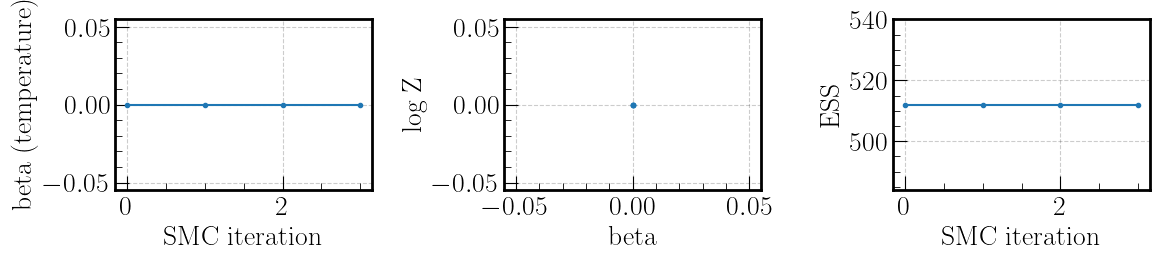

PermissionError: [Errno 13] Permission denied: '/home/tvnguyen/.cache/matplotlib/tex.cache/cf/00'

<Figure size 2020x2020 with 81 Axes>


--- posterior predictive check: flow vs simulator ---
100/100 simulations succeeded (20,000 stars); flow drew 20,000


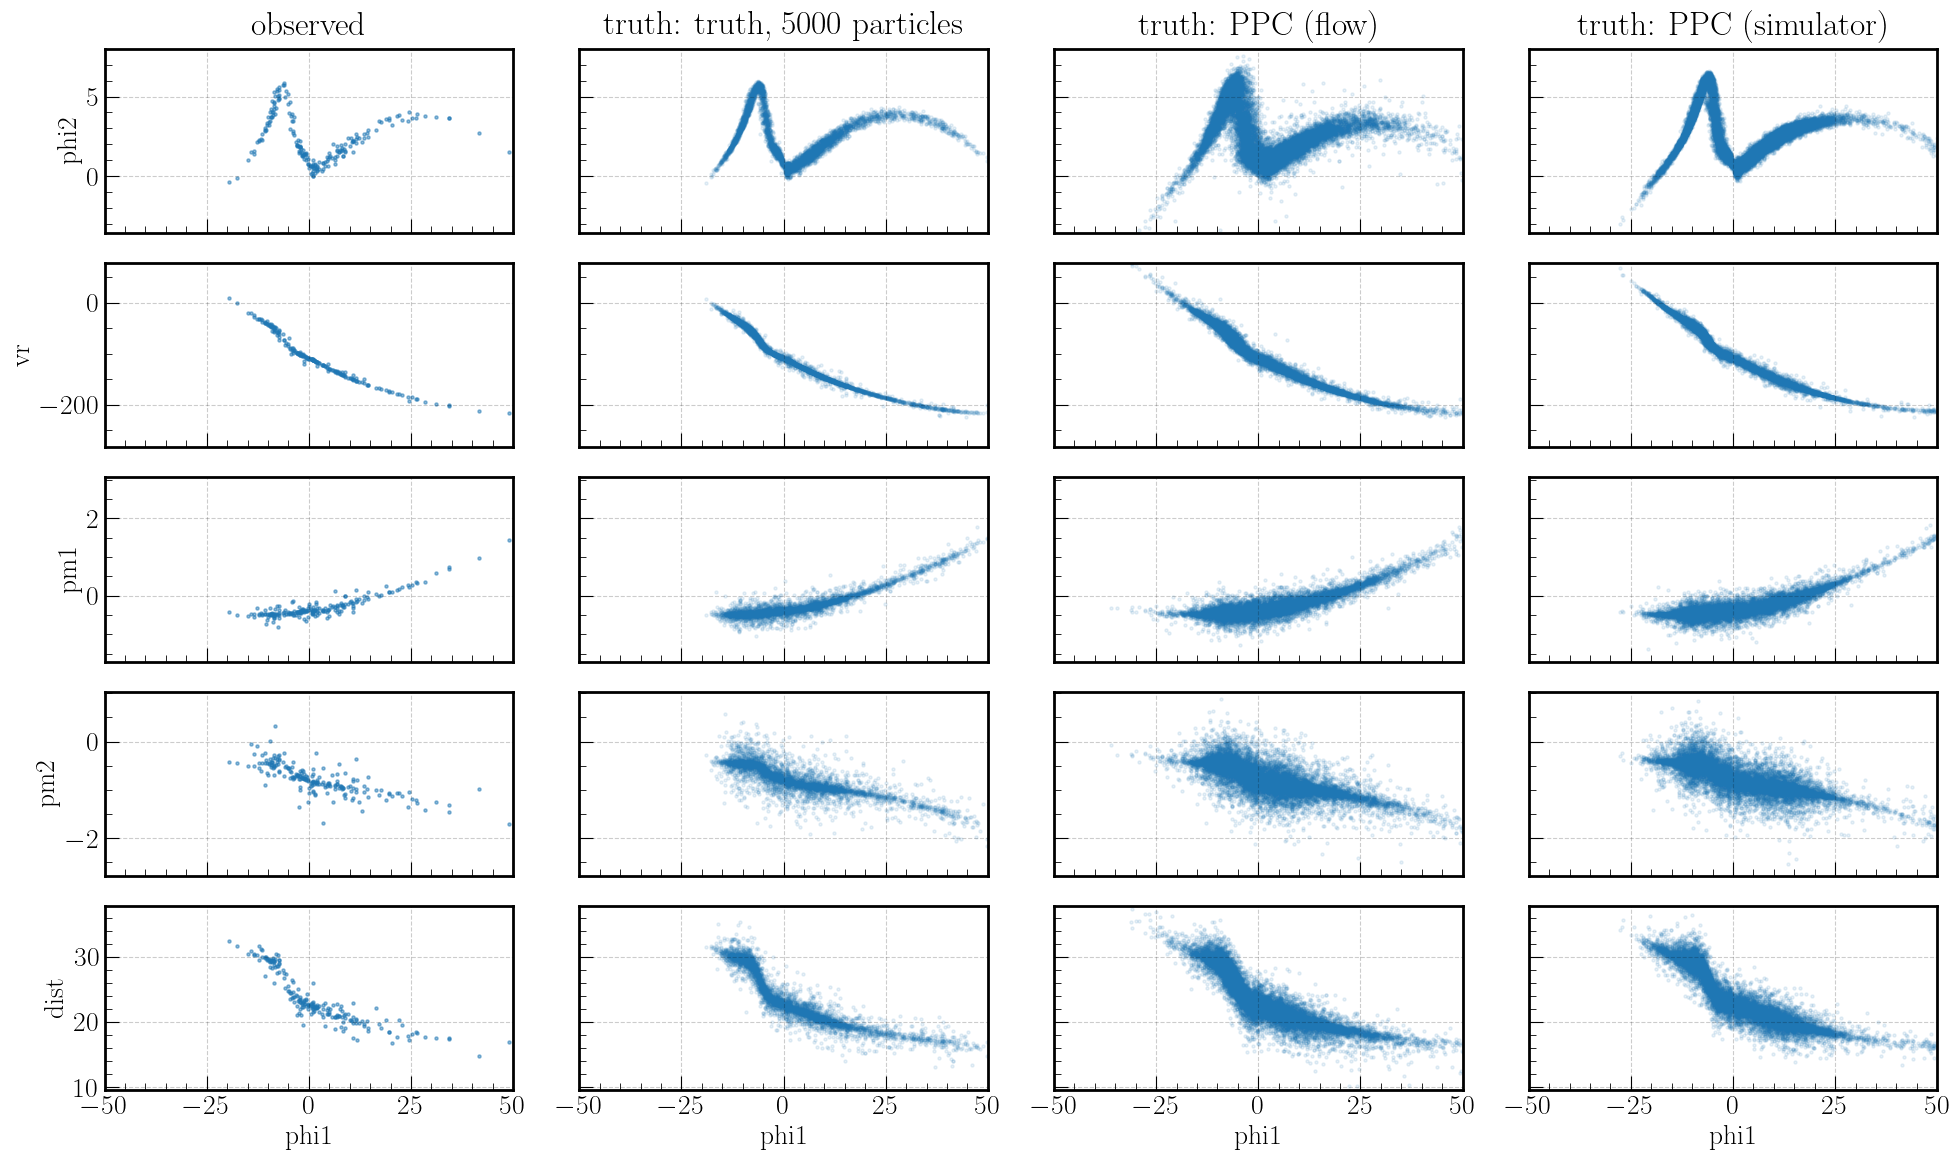

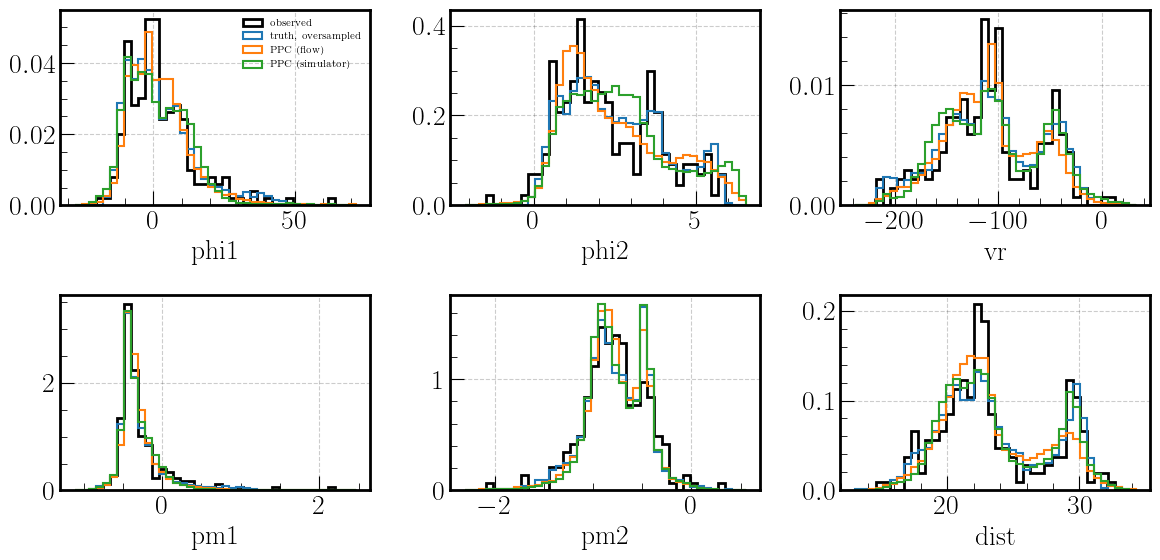

In [19]:
results['realization_0'] = analyze_observation(obs, TRUE_PARAMS, 'truth', progress=True)

## Best-fit parameters, forward modelled both ways

The posterior predictive check pools 100 draws, which hides how any single
parameter set does. This takes the `N_TOP` highest-posterior particles and
pushes each one through **both** generators at the same star count, against
the same axis limits as every earlier grid, so the flow's stream and the
simulator's stream at the *same* theta can be read against the observation
and against each other.

KS distances go with each panel. They are weak by construction -- with 200
observed stars the 5% threshold is ~0.1 and the perturber only reshapes a
short stretch of the track -- so treat them as a floor: a *large* KS is
real evidence of misfit, a small one is not evidence of a good fit.

In [20]:
def top_theta(sampler, n_top=N_TOP):
    """The `n_top` highest-posterior particles from a pocomc run.

    The prior is flat inside its box, so ranking by `logl + logp` gives the
    same order as the likelihood alone -- it only drops particles the prior
    rejected outright.

    Args:
        sampler: A finished `pocomc.Sampler`.
        n_top: Particles to keep.

    Returns:
        (thetas, logl, logp), each ordered best first.
    """
    samples, _, logl, logp = sampler.posterior()
    order = np.argsort(logl + logp)[::-1][:n_top]
    return samples[order], logl[order], logp[order]


def compare_top_fits(result, n_top=N_TOP, n_stars=N_DENSE_PARTICLES):
    """Forward model the best-fit thetas with the flow and the simulator.

    Both generators are asked for the same number of stars and conditioned
    on the same `xerr` pool, so the only difference between their panels is
    the generator itself.

    Args:
        result: One `analyze_observation` return value.
        n_top: Best-fit parameter sets to forward model.
        n_stars: Stars generated per theta, per generator.

    Returns:
        List of dicts, one per rank, holding the theta and both star sets.
    """
    obs, theta_true = result['obs'], result['theta_true']
    obs_x, xerr = to_numpy(obs.x), to_numpy(obs.xerr)
    thetas, logl, logp = top_theta(result['sampler'], n_top)

    header = f'{"rank":>5} {"log L":>11} ' + ' '.join(
        f'{lab[:9]:>9}' for lab in LABELS)
    print(header)
    print(f'{"true":>5} {"":>11} ' + ' '.join(f'{v:>9.3f}' for v in theta_true))
    for k, theta in enumerate(thetas):
        print(f'{k:>5} {logl[k]:>11.1f} '
              + ' '.join(f'{v:>9.3f}' for v in theta))

    ks_threshold = 1.36 * np.sqrt(1 / len(obs_x) + 1 / n_stars)
    out = []
    for k, theta in enumerate(thetas):
        flow_x = sample_stars(theta, n_stars, xerr)
        sim_x, n_failed = simulate_stars(theta, n_stars, xerr=xerr)
        if n_failed:
            print(f'\nrank {k}: simulator rejected this theta, skipping')
            continue

        plot_stream_grid(
            [(f'observed ({len(obs_x)} stars)', obs_x, 'k'),
             (f'rank {k}: flow', flow_x, 'C2'),
             (f'rank {k}: simulator', sim_x, 'C1')],
            TRUTH_LIMS)
        plt.show()

        print(f'rank {k} (log L = {logl[k]:.1f}): KS vs the observation, '
              f'5% level ~ {ks_threshold:.3f}')
        print(f'{"feature":>8} {"flow":>8} {"simulator":>10}')
        for col, label in enumerate(X_LABELS):
            print(f'{label:>8} '
                  f'{ks_2samp(obs_x[:, col], flow_x[:, col]).statistic:>8.3f} '
                  f'{ks_2samp(obs_x[:, col], sim_x[:, col]).statistic:>10.3f}')
        print()
        out.append(dict(rank=k, theta=theta, logl=float(logl[k]),
                        logp=float(logp[k]), flow=flow_x, sim=sim_x))
    return out

 rank       log L  log_mass log_radiu v_rel_per v_rel_par angle_pos angle_vel impact_pa time_impa phi1_impa
 true                 1.000    -0.523    35.000    10.000     0.000    45.000     1.000     0.250    -8.000
    0      4627.3     0.950    -0.638    37.364    15.012    23.954    17.985     1.795     0.232    -8.005
    1      4627.2     0.977    -0.607    37.852    15.134    24.695    18.096     1.553     0.231    -8.007
    2      4627.1     0.951    -0.631    37.090    14.432    24.246    17.819     1.596     0.234    -8.021


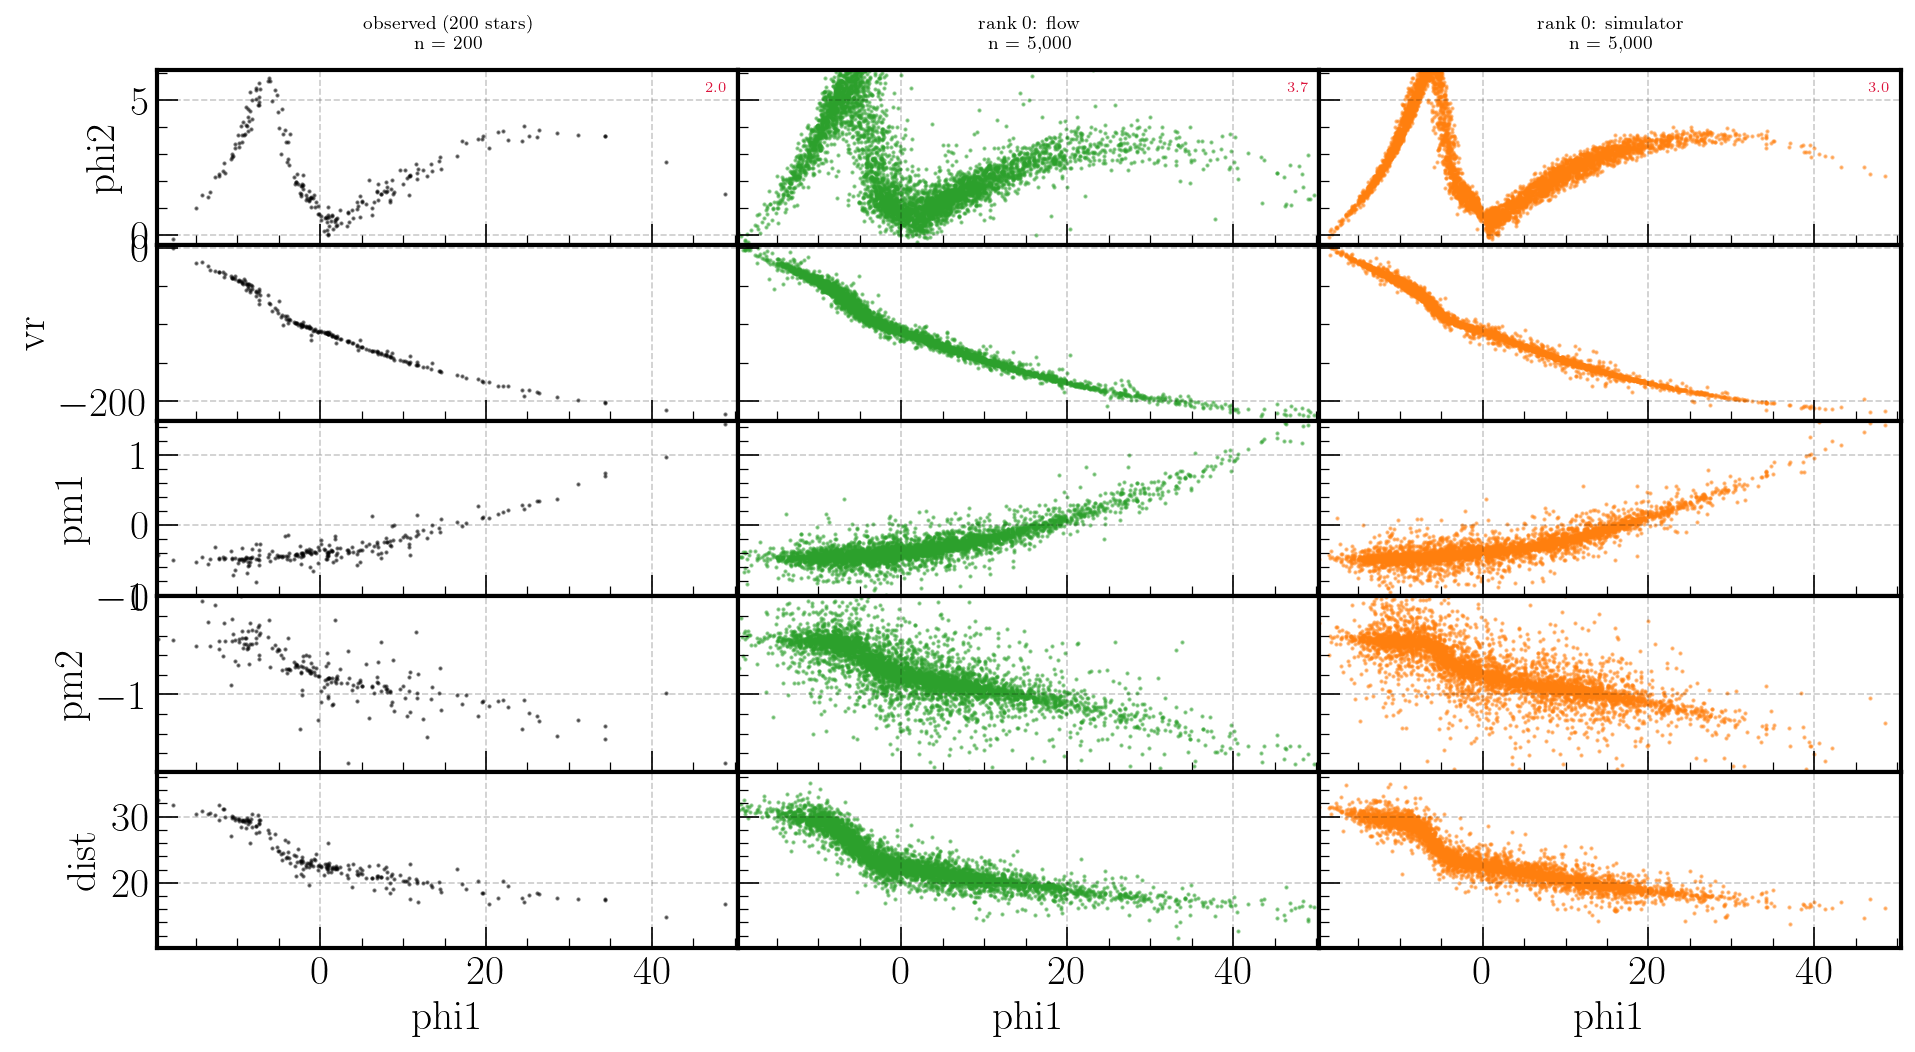

rank 0 (log L = 4627.3): KS vs the observation, 5% level ~ 0.098
 feature     flow  simulator
    phi1    0.065      0.063
    phi2    0.064      0.138
      vr    0.059      0.062
     pm1    0.086      0.068
     pm2    0.044      0.056
    dist    0.085      0.054



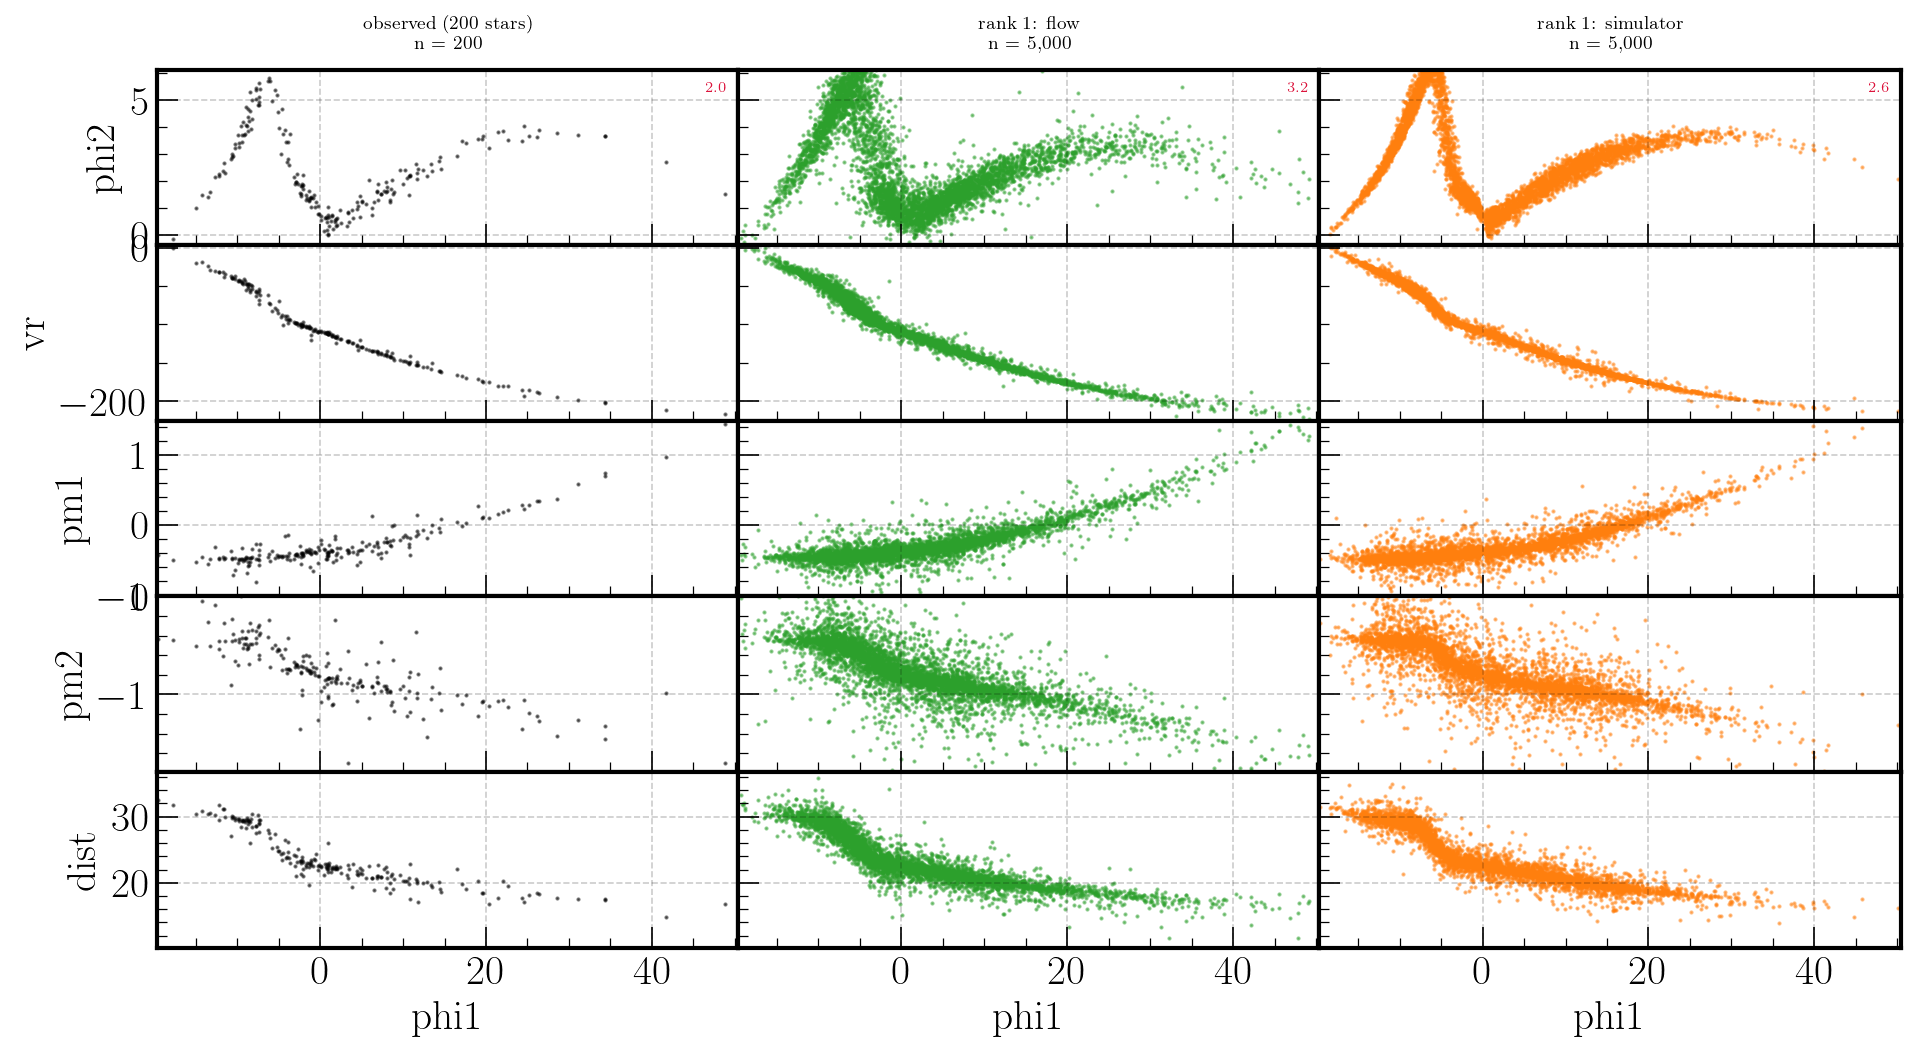

rank 1 (log L = 4627.2): KS vs the observation, 5% level ~ 0.098
 feature     flow  simulator
    phi1    0.065      0.063
    phi2    0.077      0.143
      vr    0.065      0.062
     pm1    0.104      0.070
     pm2    0.039      0.055
    dist    0.088      0.054



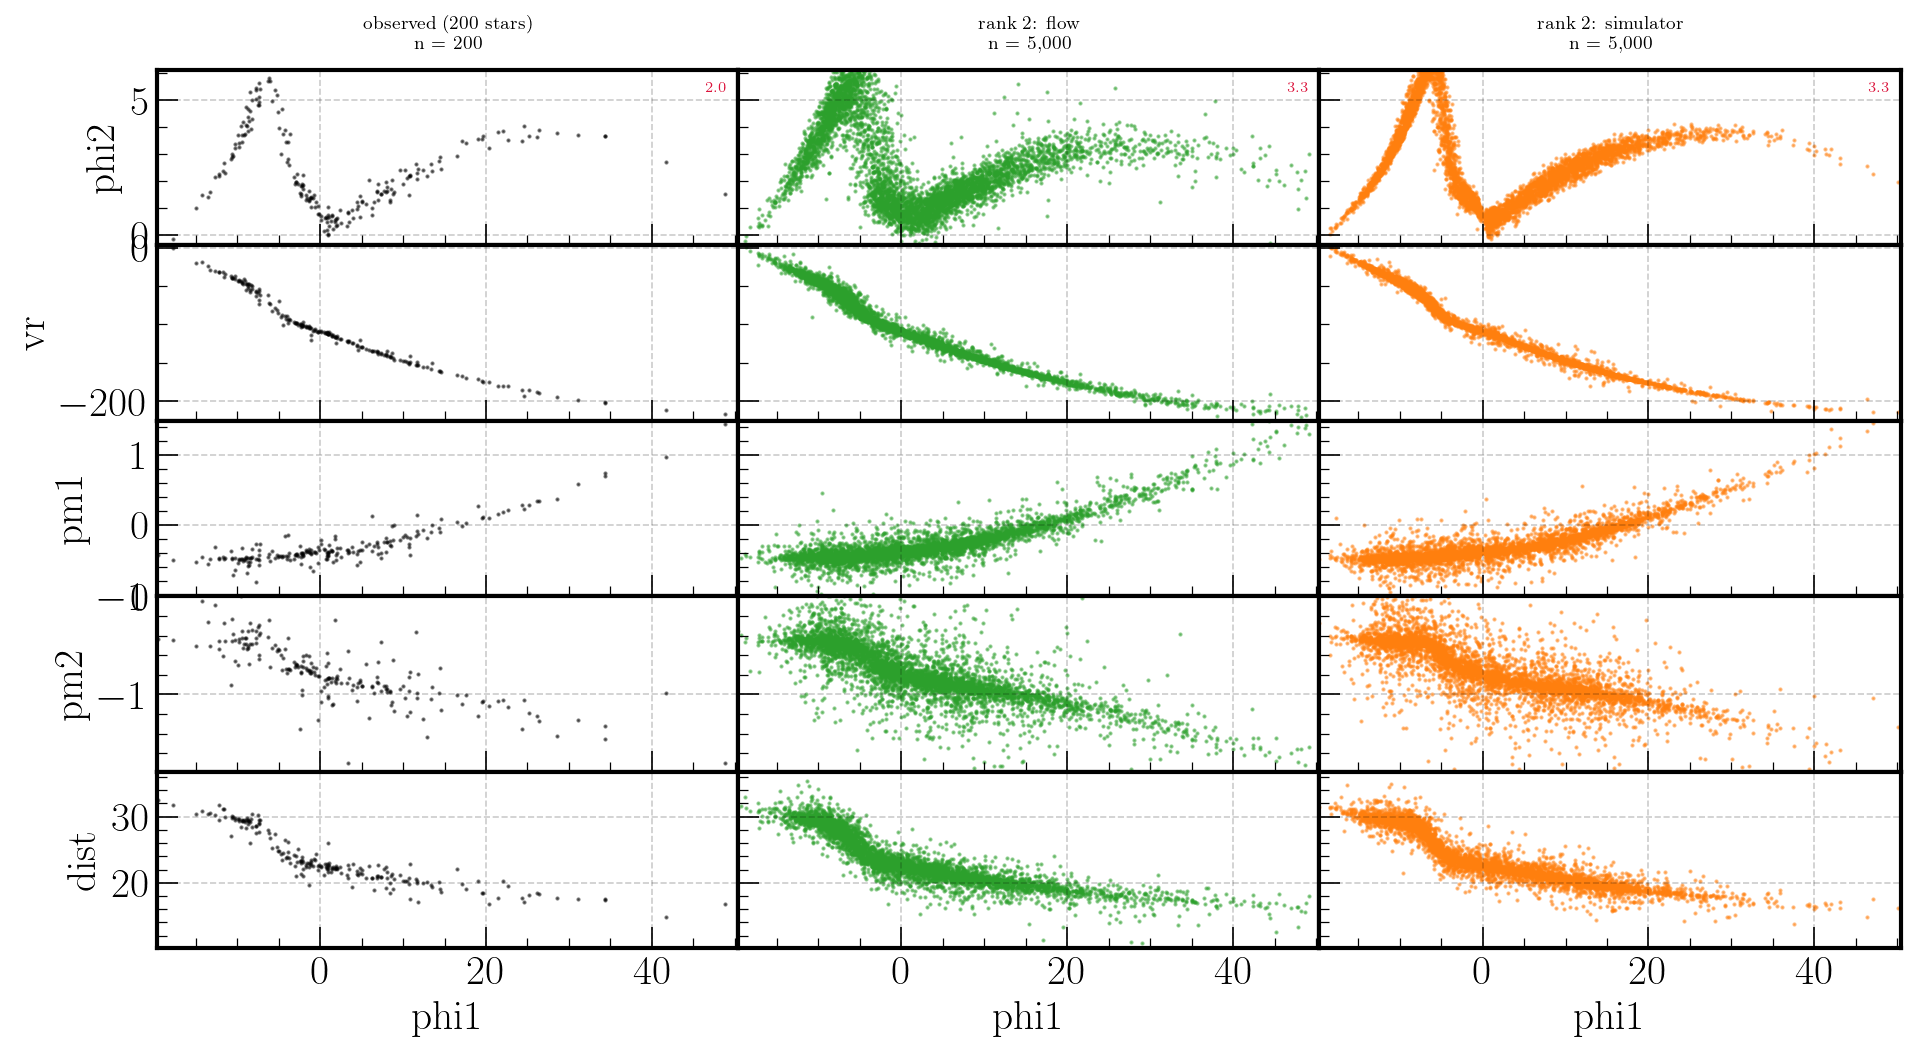

rank 2 (log L = 4627.1): KS vs the observation, 5% level ~ 0.098
 feature     flow  simulator
    phi1    0.057      0.063
    phi2    0.069      0.142
      vr    0.051      0.060
     pm1    0.094      0.068
     pm2    0.033      0.055
    dist    0.077      0.055



In [21]:
top_fits = compare_top_fits(results['realization_0'], n_stars=5000)